In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from oracle.custom_datasets.BTS import BTS_val_parquet_path, BTS_test_parquet_path, BTS_train_parquet_path

In [3]:
colors = {1: 'mediumaquamarine', 2: 'crimson', 3: 'goldenrod'}
filters = {1: 'g', 2: 'r', 3: 'i'}
markers = {1: 'o', 2: 's', 3: '^'}

In [4]:
val_df = pd.read_parquet(BTS_val_parquet_path)
test_df = pd.read_parquet(BTS_test_parquet_path)


In [5]:
df = pd.concat([val_df, test_df], ignore_index=True)

In [168]:
def plot_ztf_sample(id, x_label=False, save=True):

    x_size = 3.5 if x_label else 3.2

    gs_kw = dict(width_ratios=[3, 1], height_ratios=[2, 1])
    fig, axd = plt.subplot_mosaic([['left', 'upper right'],
                                ['left', 'lower right']],
                                    gridspec_kw=gs_kw,
                                figsize=(8.5, x_size), layout="constrained")
    for k in ['upper right', 'lower right']:
        axd[k].set_xticks([])
        axd[k].set_yticks([])

    sample = df[df['ZTFID'] == id]
    label = sample['bts_class'].to_numpy()[0]

    t = sample['jd'].to_numpy()[0]
    t = t - np.min(t)

    mag = sample['magpsf'].to_numpy()[0]
    mag_err = sample['sigmapsf'].to_numpy()[0]
    band = sample['fid'].to_numpy()[0]

    ra = sample['ra'].to_numpy()[0][0]
    dec = sample['dec'].to_numpy()[0][0]
    drb = sample['drb'].to_numpy()[0][0]
    sgscore = sample['sgscore1'].to_numpy()[0][0]
    scorr = sample['scorr'].to_numpy()[0][0]


    for b in np.unique(band):
        mask = band == b
        axd['left'].errorbar(t[mask], mag[mask], yerr=mag_err[mask], fmt=markers[b], label=filters[b], color=colors[b], mec='white', markersize=10)

    axd['left'].text(0.05, 0.1, f"{id} ({label})", transform=axd['left'].transAxes, fontsize='xx-large', verticalalignment='top')
    axd['left'].set_ylim(top=20.8)

    axd['left'].invert_yaxis()
    if x_label:
        axd['left'].set_xlabel('Days since first detection', fontsize='xx-large')
    axd['left'].set_ylabel('AB magnitude', fontsize='xx-large')

    ps_data = sample['ps'].iloc[0]

    img = np.asarray(ps_data).reshape((3, 252, 252))
    img = np.permute_dims(img, (1,2,0))  # swap x and y for correct orientation

    axd['upper right'].imshow(img)


    text = f"RA: {ra:.3f}\nDec: {dec:.3f}\nsgscore: {sgscore:.2f}\nscorr: {scorr:.2f}"

    axd['lower right'].text(0, 0, text, transform=axd['lower right'].transAxes,
                        fontsize='x-large', color='black', ha='left', va='bottom')   
    axd['lower right'].axis('off') 


    # make legend a separate figure
    fig_legend = plt.figure(figsize=(3, 1))
    ax_legend = fig_legend.add_subplot()
    for b in np.unique(band):
        mask = band == b
        ax_legend.plot([], [], markers[b], label=filters[b], color=colors[b])
    # make it 3 column
    ax_legend.legend(ncol=3)
    ax_legend.axis('off')

    # only keep y ticks for integer magnitudes
    yticks = axd['left'].get_yticks()
    axd['left'].set_yticks(yticks[yticks % 1 == 0])

    # make x and y tick labels larger
    axd['left'].tick_params(axis='both', which='major', labelsize='x-large')       

    axd['left'].grid(True, alpha=0.2)

    if save:
        fig.savefig(f"{label}_{id}.pdf")
        fig_legend.savefig(f"legend.pdf")
    else:
        plt.show()

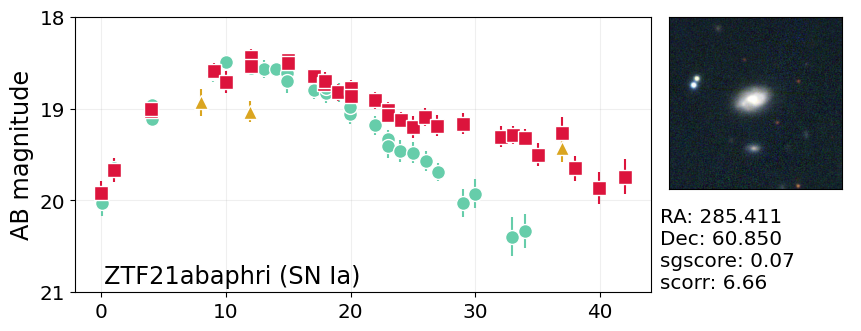

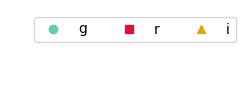

In [169]:
plot_ztf_sample("ZTF21abaphri")

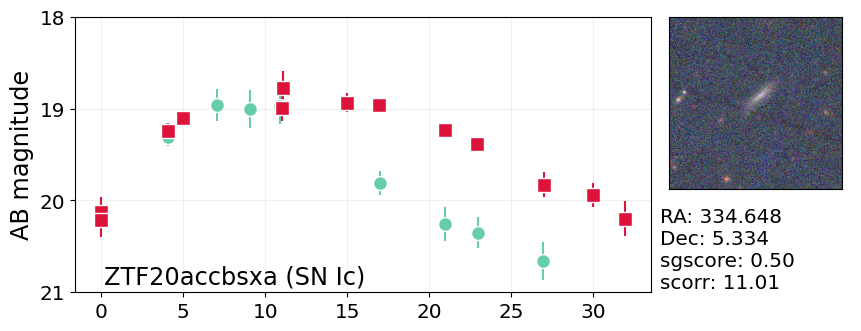

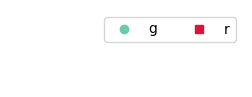

In [170]:
plot_ztf_sample("ZTF20accbsxa")

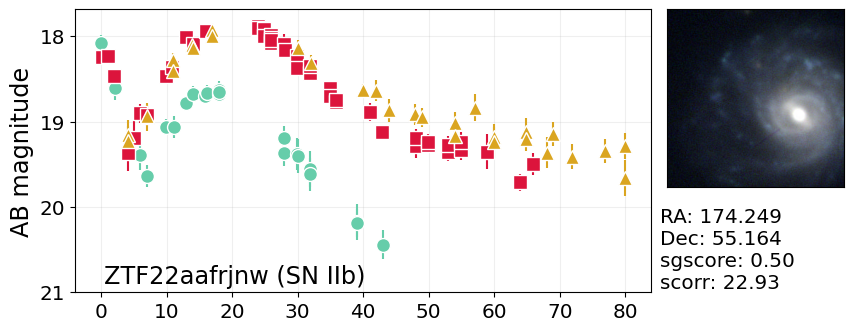

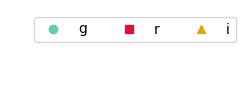

In [171]:
plot_ztf_sample("ZTF22aafrjnw")

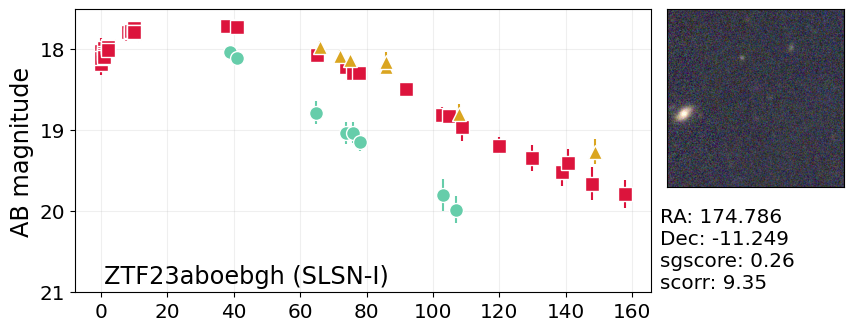

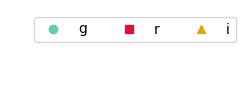

In [172]:
plot_ztf_sample("ZTF23aboebgh")

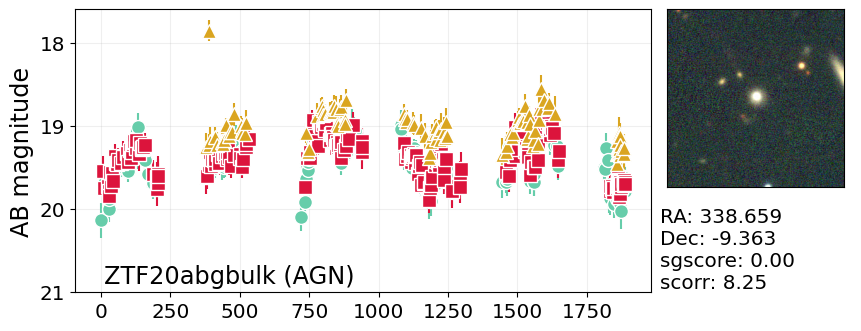

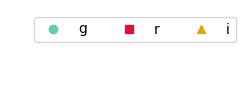

In [173]:
plot_ztf_sample("ZTF20abgbulk")

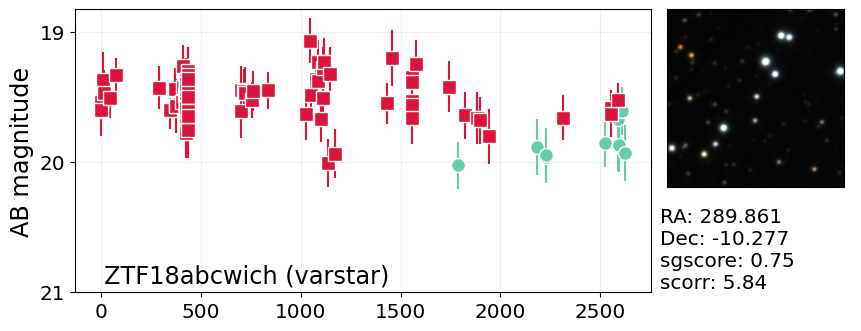

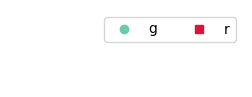

In [174]:
plot_ztf_sample("ZTF18abcwich")

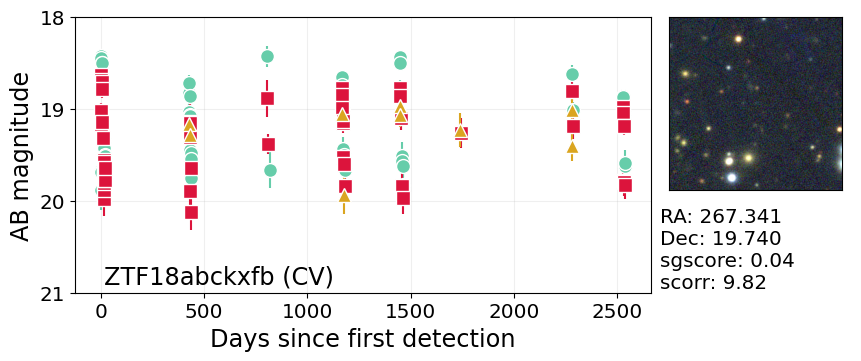

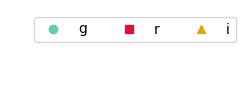

In [175]:
plot_ztf_sample("ZTF18abckxfb", x_label=True)

In [76]:
# shuffle the df
df.sample(frac=1).reset_index(drop=True)

,ZTFID,bts_class,objectId,jd,label,fid,diffmaglim,programid,candid,isdiffpos,...,nondet_jd,nondet_diffmaglim,W1mag,W2mag,W3mag,W4mag,ps,g_reference,r_reference,i_reference
0,ZTF18abccmkn,AGN,"[ZTF18abccmkn, ZTF18abccmkn, ZTF18abccmkn, ZTF...","[2458287.9193171, 2458290.9192477, 2458293.918...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, ...","[20.69546127319336, 20.84534072875977, 20.4699...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[533419311815015003, 536419241815015002, 53941...","[t, t, t, t, t, t, t, t, t, t, t, t, t, t, t, ...",...,None,None,13.133,12.454,9.119,6.729,"[0.007843137718737125, 0.007843137718737125, 0...","[0.015430846251547337, 0.015547903254628181, 0...","[0.015775131061673164, 0.015707513317465782, 0...","[0.01626627892255783, 0.01616382598876953, 0.0..."
1,ZTF20abawtpy,SN Ia,"[ZTF20abawtpy, ZTF20abawtpy, ZTF20abawtpy, ZTF...","[2458991.8248843, 2458994.8172917, 2458994.902...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 2, 1, 1, 3, 2, 2, 1, 2, 1, 2, 1, 2, 3, 1, ...","[20.89562225341797, 20.663585662841797, 20.883...","[1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, ...","[1237324881115015007, 1240317291115015006, 124...","[t, t, t, t, t, t, t, t, t, t, t, t, t, t, t, ...",...,None,None,12.492,12.322,8.464,6.513,"[0.03921568766236305, 0.03529411926865578, 0.0...","[0.015003351494669914, 0.015041099861264229, 0...","[0.014945890754461288, 0.015185064636170864, 0...","[0.015349307097494602, 0.015536016784608364, 0..."
2,ZTF20aazewcq,SN Ia,"[ZTF20aazewcq, ZTF20aazewcq, ZTF20aazewcq, ZTF...","[2458979.9384259, 2458979.9601273, 2458987.957...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 2, 1, 2, 1, 1, 2, 2, 1, 2, 1, 1, 2, 2, 2, ...","[18.98841667175293, 19.24860191345215, 20.6477...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1225438423215015001, 1225460123215015002, 123...","[t, t, t, t, t, t, t, t, t, t, t, t, t, t, t, ...",...,None,None,-9.000,-9.000,-9.000,-9.000,"[0.24313725531101227, 0.23529411852359772, 0.1...","[0.016005393117666245, 0.015820946544408798, 0...","[0.01576070301234722, 0.015455213375389576, 0....",None
3,ZTF19aahvneb,AGN,"[ZTF19aahvneb, ZTF19aahvneb, ZTF19aahvneb, ZTF...","[2458522.7347685, 2458522.7495486, 2458522.770...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, ...","[20.497692108154297, 20.574403762817383, 20.66...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, ...","[768234762215015010, 768249542215015015, 76827...","[t, t, t, t, t, t, t, t, t, t, t, t, t, t, t, ...",...,None,None,12.647,11.869,9.381,7.646,"[0.027450980618596077, 0.027450980618596077, 0...","[0.015971926972270012, 0.01590104028582573, 0....","[0.016068516299128532, 0.016197597607970238, 0...","[0.01617099717259407, 0.01611224189400673, 0.0..."
4,ZTF23aayngri,SN IIn,"[ZTF23aayngri, ZTF23aayngri, ZTF23aayngri, ZTF...","[2460173.9611458, 2460182.8792361, 2460209.798...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, ...","[20.23786163330078, 20.191429138183594, 19.273...","[1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2419461145515015002, 2428379235515015001, 245...","[t, t, t, t, t, t, t, t, t, t, t, t, t, t, t, ...",...,None,None,-9.000,-9.000,-9.000,-9.000,"[0.1411764770746231, 0.4117647111415863, 0.231...","[0.016028624027967453, 0.01605052687227726, 0....","[0.01583751104772091, 0.015789151191711426, 0....",None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2992,ZTF22aavqlzi,SN Ia,"[ZTF22aavqlzi, ZTF22aavqlzi, ZTF22aavqlzi, ZTF...","[2459790.7941319, 2459792.7723032, 2459794.814...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1]","[19.8535213470459, 19.041183471679688, 20.0287...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2]","[2036294136115015017, 2038272306115015022, 204...","[t, t, t, t, t, t, t, t, t, t, 

: 

: 

: 

: 